# Ablation Study for Surfactant CMC Prediction Model

This notebook demonstrates how to perform ablation studies on your surfactant model to understand the contributions of hydrophilic (head) and hydrophobic (tail) groups.

## 1. Setup and Imports

In [1]:
import os
import sys
base_dir = 'C:\\Users\\gtheis2\\git\\surfactant_project\\to-realeased\\GCN-GAT-PharmaHGT'
# requirements_path = 'C:\\Users\\gtheis2\\git\\surfactant_project\\to-realeased\\GCN-GAT-PharmaHGT
src_dir = os.path.join(base_dir, "src/PharmaHGT")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
    
print(f"Added {src_dir} to sys.path")

Added C:\Users\gtheis2\git\surfactant_project\to-realeased\GCN-GAT-PharmaHGT\src/PharmaHGT to sys.path


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Import the ablation study module
from ablation_study import SimpleAblationStudy

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.0
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060


## 2. Load Your Trained Model

In [6]:
# Common parts of the path
model_root = os.path.join(base_dir, 'models/PharmaHGT')
model_name = 'surfactant_model_data2_newSplit70_20_10_plot_opt_R9'
seed = 'seed_2022'
fold = 'fold_0'

# Construct full folder paths
model_folder = os.path.join(model_root, model_name, seed, fold)

# === Specific paths ===
model_path = os.path.join(model_root, model_name, seed, fold, 'best_fold0.pt')
config_path = os.path.join(model_root, model_name, seed, 'config_data2_R9.json')
data_path = os.path.join(model_root, model_name, seed, fold, '2022_fold_0_test.csv')

print("Model path:", model_path)
print("Config path:", config_path)
print("Data path:", data_path)

# Initialize the ablation study
print("Loading model...")
ablation = SimpleAblationStudy(model_path, config_path, save_dir= model_folder)
print("Model loaded successfully!")

Model path: C:\Users\gtheis2\git\surfactant_project\to-realeased\GCN-GAT-PharmaHGT\models/PharmaHGT\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\fold_0\best_fold0.pt
Config path: C:\Users\gtheis2\git\surfactant_project\to-realeased\GCN-GAT-PharmaHGT\models/PharmaHGT\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\config_data2_R9.json
Data path: C:\Users\gtheis2\git\surfactant_project\to-realeased\GCN-GAT-PharmaHGT\models/PharmaHGT\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\fold_0\2022_fold_0_test.csv
Loading model...
Using device: cuda
Model loaded from epoch 84
Model loaded successfully!


## 3. Single Molecule Analysis

Let's start by analyzing individual surfactant molecules to understand how ablation affects predictions.

In [ ]:
# # Define some example surfactants
# example_surfactants = {
#     'Sodium Dodecyl Sulfate (SDS)': 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]',
#     'Cetyltrimethylammonium Bromide (CTAB)': 'CCCCCCCCCCCCCCCC[N+](C)(C)C.[Br-]',
#     'Sodium Laurate': 'CCCCCCCCCCCC(=O)[O-].[Na+]',
#     'Octyl Glucoside': 'CCCCCCCCOCC1OC(CO)C(O)C(O)C1O',
#     'Dodecylbenzene Sulfonate': 'CCCCCCCCCCCCc1ccc(S(=O)(=O)[O-])cc1.[Na+]'
# }

# # Analyze each surfactant
# individual_results = {}

# for name, smiles in example_surfactants.items():
#     print(f"\n{'='*60}")
#     results = ablation.analyze_molecule(smiles, name)
#     individual_results[name] = results



Analyzing: Sodium Dodecyl Sulfate (SDS)
Surfactant type: anionic
Head atoms: 6 / 18
Tail atoms: 12 / 18

Predictions:
  none           : 1.104
  remove_head    : 1.086
  remove_tail    : 1.141
  remove_both    : 1.136
  zero_head      : 0.878
  zero_tail      : 1.087

Impact Analysis (ΔlogCMC):
  remove_head    : -0.018 (-1.6%)
  remove_tail    : +0.037 (+3.3%)
  remove_both    : +0.032 (+2.9%)
  zero_head      : -0.226 (-20.5%)
  zero_tail      : -0.017 (-1.6%)


Analyzing: Cetyltrimethylammonium Bromide (CTAB)
Surfactant type: cationic
Head atoms: 6 / 21
Tail atoms: 16 / 21

Predictions:
  none           : 0.165
  remove_head    : 0.087
  remove_tail    : 0.336
  remove_both    : 1.086
  zero_head      : 0.087
  zero_tail      : 1.058

Impact Analysis (ΔlogCMC):
  remove_head    : -0.079 (-47.6%)
  remove_tail    : +0.170 (+102.9%)
  remove_both    : +0.921 (+557.0%)
  zero_head      : -0.079 (-47.6%)
  zero_tail      : +0.892 (+539.8%)


Analyzing: Sodium Laurate
Surfactant type: 

## 4. Visualize Individual Results

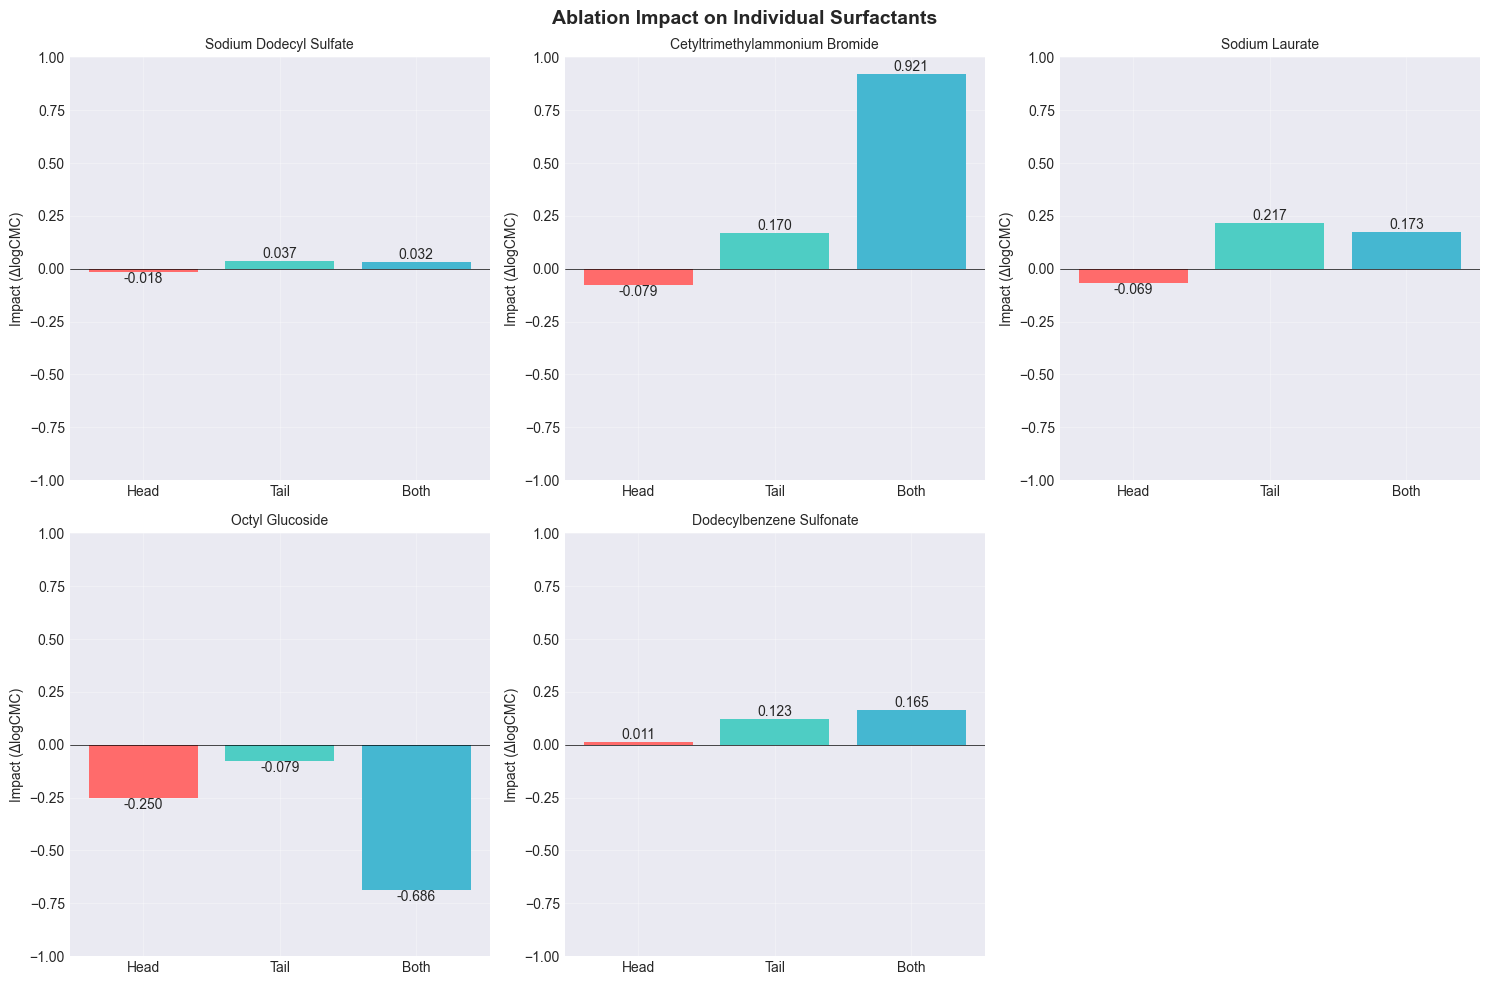

In [ ]:
# # Create a comparison plot for individual surfactants
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for idx, (name, results) in enumerate(individual_results.items()):
#     if idx >= 5:
#         break
    
#     ax = axes[idx]
    
#     # Calculate impacts
#     baseline = results['none']
#     impacts = {
#         'Head': results['remove_head'] - baseline,
#         'Tail': results['remove_tail'] - baseline,
#         'Both': results['remove_both'] - baseline
#     }
    
#     # Plot bars
#     colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
#     bars = ax.bar(impacts.keys(), impacts.values(), color=colors)
    
#     # Add value labels on bars
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2., height,
#                 f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top')
    
#     ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
#     ax.set_ylabel('Impact (ΔlogCMC)')
#     ax.set_title(name.split('(')[0].strip(), fontsize=10)
#     ax.grid(True, alpha=0.3)
#     ax.set_ylim(-1, 1)

# # Remove extra subplot
# if len(individual_results) < 6:
#     fig.delaxes(axes[5])

# plt.suptitle('Ablation Impact on Individual Surfactants', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

## 5. Batch Analysis on Test Dataset

Running batch ablation analysis...
This may take a few minutes depending on the number of molecules.



Processing molecules: 100%|██████████| 73/73 [00:31<00:00,  2.33it/s]



ABLATION STUDY SUMMARY
Analyzed 73 molecules

Average Impacts (ΔlogCMC):
  Head removal: -0.285 ± 0.358
  Tail removal: 0.362 ± 0.686
  Both removal: 0.110 ± 0.949

Average Importance (|ΔlogCMC|):
  Head: 0.310
  Tail: 0.512


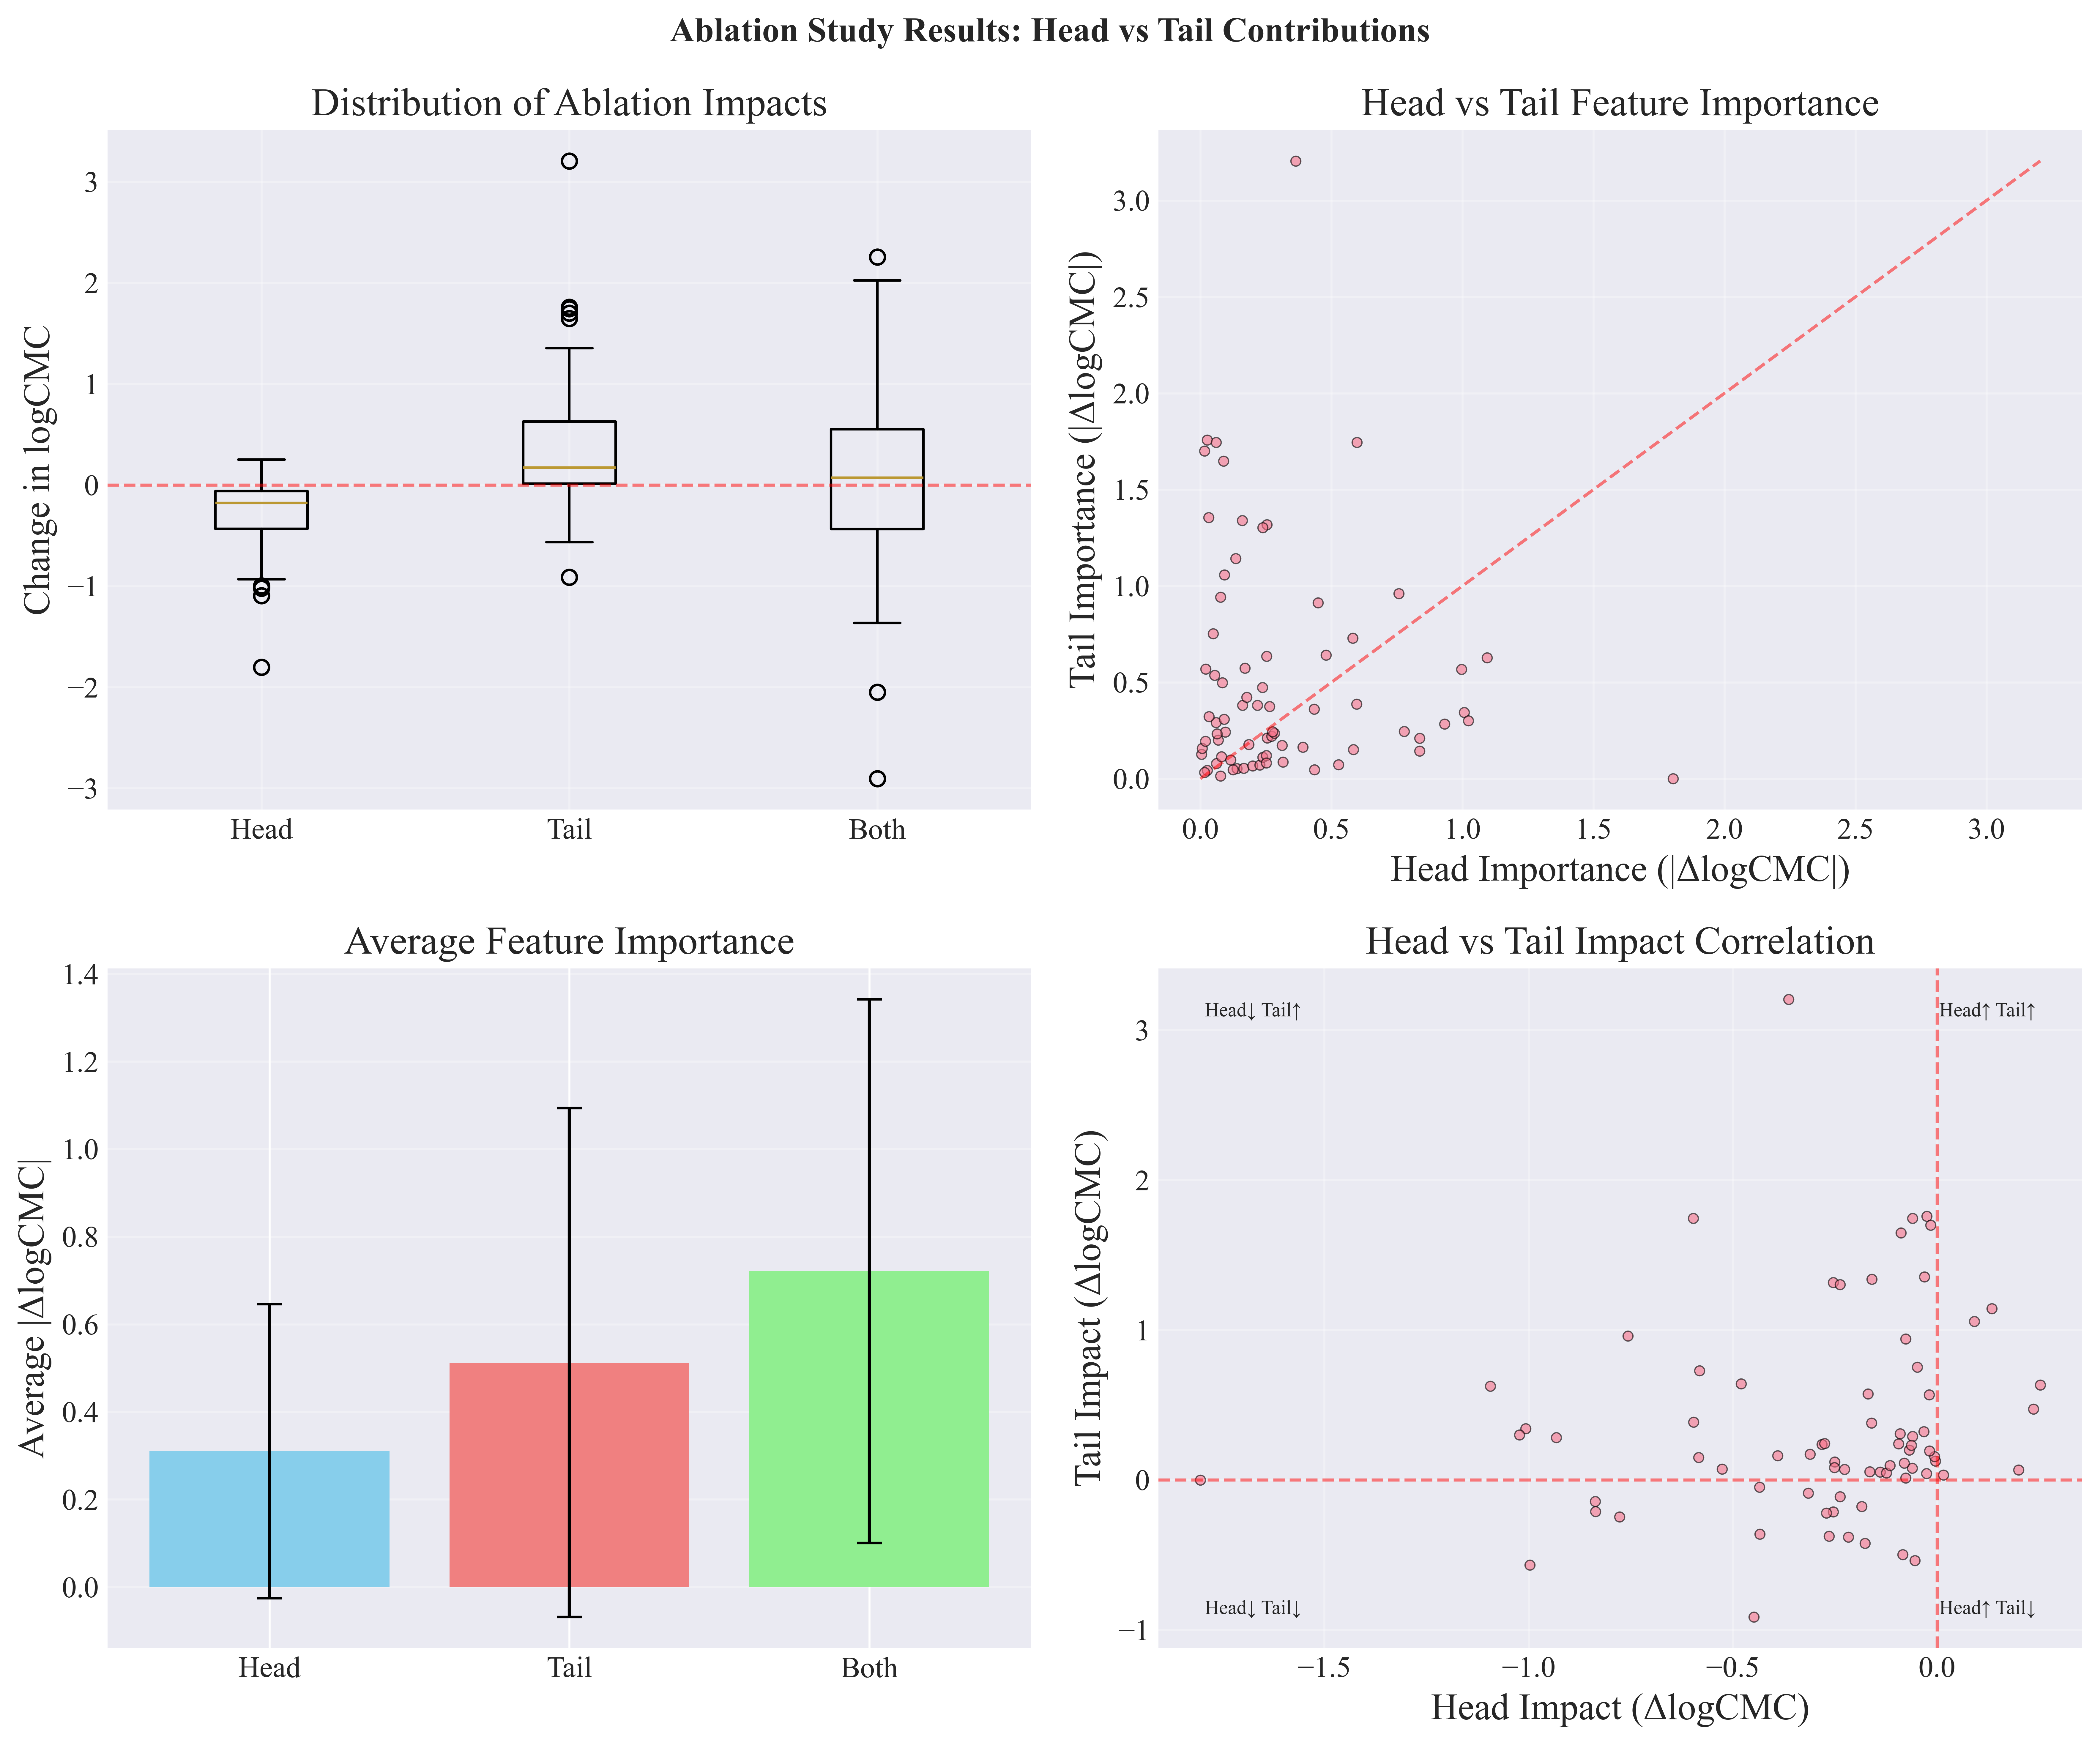


First 5 rows of results:


,smiles,baseline_prediction,head_impact,tail_impact,both_impact,head_importance,tail_importance,zero_head_impact,zero_tail_impact,actual_logCMC,baseline_error
0,CCCCCCCCCCOCCOCCOCCOCCO,-0.247652,-0.581626,0.728684,0.198208,0.581626,0.728684,-1.429761,0.728684,-0.168770,-0.078881
1,CCCCCCCCO[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@...,1.050307,-0.836511,-0.143114,-0.641770,0.836511,0.143114,-0.836511,-0.143114,1.301030,-0.250723
2,CCCCCCCCC=CCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O...,-2.007429,-0.031201,1.354665,1.452165,0.031201,1.354665,-0.053585,1.354665,-1.698970,-0.308459
3,CCCCCCCC(=O)OCC(OCCOCCO)C1OCC(OCCOCCO)C1OCCOCC...,-0.280483,-0.139416,0.052771,-0.467883,0.139416,0.052771,-0.766275,0.052771,-0.349692,0.069210
4,CCCCCCCC(=O)OCC(OCCOCCOCCO)C1OCC(OCCOCCO)C1OCC...,-0.260638,-0.164641,0.054397,-0.553406,0.164641,0.054397,-0.835123,0.054397,-0.349692,0.089054



Summary statistics:


,head_impact,tail_impact,both_impact,head_importance,tail_importance
count,73.000000,73.000000,73.000000,73.000000,73.000000
mean,-0.284818,0.361578,0.110041,0.310278,0.512408
std,0.357995,0.686323,0.948858,0.335856,0.580849
min,-1.803144,-0.913435,-2.905259,0.004131,0.000189
25%,-0.433583,0.013292,-0.436753,0.077093,0.126414
50%,-0.176466,0.172656,0.071727,0.216926,0.291190
75%,-0.059988,0.626758,0.550168,0.433583,0.634648
max,0.252498,3.204913,2.255816,1.803144,3.204913


In [4]:
# Run ablation on a batch of molecules from your test set
print("Running batch ablation analysis...")
print("This may take a few minutes depending on the number of molecules.\n")

# Analyze 50 molecules (adjust as needed)
results_df = ablation.batch_analysis(data_path, num_samples=73)

# Display summary statistics
print("\nFirst 5 rows of results:")
display(results_df.head())

print("\nSummary statistics:")
display(results_df[['head_impact', 'tail_impact', 'both_impact', 
                     'head_importance', 'tail_importance']].describe())

## 6. Statistical Analysis

In [5]:
# Perform statistical tests
from scipy import stats


# import matplotlib as mpl
# import matplotlib.pyplot as plt
 
# mpl.rcParams['lines.linewidth'] = 1.25 # sets linedwidth
# mpl.rcParams['lines.markersize'] = 4 # sets marker-size on lines
# mpl.rcParams['figure.dpi'] = 150 # sets dpi
 
# plt.rcParams.update({
#      "text.usetex": 1,
#      "font.family": "serif",
#      "font.sans-serif": ["Times"],
#      "font.size": 15})

# Test if head and tail impacts are significantly different from zero
head_ttest = stats.ttest_1samp(results_df['head_impact'].dropna(), 0)
tail_ttest = stats.ttest_1samp(results_df['tail_impact'].dropna(), 0)

print("Statistical Significance Tests:")
print("="*50)
print(f"Head impact vs. zero: t={head_ttest.statistic:.3f}, p={head_ttest.pvalue:.4f}")
print(f"Tail impact vs. zero: t={tail_ttest.statistic:.3f}, p={tail_ttest.pvalue:.4f}")

# Test if head and tail impacts are different
paired_ttest = stats.ttest_rel(results_df['head_impact'].dropna(), 
                               results_df['tail_impact'].dropna())
print(f"\nHead vs. Tail impact: t={paired_ttest.statistic:.3f}, p={paired_ttest.pvalue:.4f}")

# Calculate correlation
correlation = results_df[['head_impact', 'tail_impact']].corr()
print(f"\nCorrelation between head and tail impacts:")
display(correlation)

Statistical Significance Tests:
Head impact vs. zero: t=-6.798, p=0.0000
Tail impact vs. zero: t=4.501, p=0.0000

Head vs. Tail impact: t=-7.611, p=0.0000

Correlation between head and tail impacts:


,head_impact,tail_impact
head_impact,1.000000,0.147778
tail_impact,0.147778,1.000000


## 7. Advanced Visualizations

In [6]:
# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribution comparison
ax1 = fig.add_subplot(gs[0, :])
positions = [1, 2, 3]
data = [results_df['head_impact'].dropna(), 
        results_df['tail_impact'].dropna(), 
        results_df['both_impact'].dropna()]
parts = ax1.violinplot(data, positions=positions, showmeans=True, showmedians=True)
ax1.set_xticks(positions)
ax1.set_xticklabels(['Head Ablation', 'Tail Ablation', 'Both Ablation'])
ax1.set_ylabel('Impact (ΔlogCMC)', fontsize=12)
ax1.set_title('Distribution of Ablation Impacts', fontsize=14, fontweight='bold')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

# 2. Importance comparison
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(results_df['head_importance'], results_df['tail_importance'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Head Importance |ΔlogCMC|', fontsize=11)
ax2.set_ylabel('Tail Importance |ΔlogCMC|', fontsize=11)
ax2.set_title('Feature Importance Comparison', fontsize=12)
# Add diagonal line
max_val = max(results_df['head_importance'].max(), results_df['tail_importance'].max())
ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Impact correlation
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(results_df['head_impact'], results_df['tail_impact'], 
           alpha=0.6, s=50, c=results_df['baseline_prediction'], cmap='coolwarm')
ax3.set_xlabel('Head Impact (ΔlogCMC)', fontsize=11)
ax3.set_ylabel('Tail Impact (ΔlogCMC)', fontsize=11)
ax3.set_title('Impact Correlation', fontsize=12)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.colorbar(ax3.collections[0], ax=ax3, label='Baseline Prediction')
ax3.grid(True, alpha=0.3)

# 4. Cumulative importance
ax4 = fig.add_subplot(gs[1, 2])
cumulative_data = pd.DataFrame({
    'Head': np.sort(results_df['head_importance'].abs()),
    'Tail': np.sort(results_df['tail_importance'].abs())
})
cumulative_data['Index'] = range(len(cumulative_data))
ax4.plot(cumulative_data['Index'], cumulative_data['Head'].cumsum(), label='Head', linewidth=2)
ax4.plot(cumulative_data['Index'], cumulative_data['Tail'].cumsum(), label='Tail', linewidth=2)
ax4.set_xlabel('Molecules (sorted by importance)', fontsize=11)
ax4.set_ylabel('Cumulative Importance', fontsize=11)
ax4.set_title('Cumulative Feature Importance', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Histogram of impacts
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(results_df['head_impact'], bins=20, alpha=0.5, label='Head', color='blue')
ax5.hist(results_df['tail_impact'], bins=20, alpha=0.5, label='Tail', color='red')
ax5.set_xlabel('Impact (ΔlogCMC)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Impact Distribution', fontsize=12)
ax5.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Box plot comparison
ax6 = fig.add_subplot(gs[2, 1])
results_df[['head_importance', 'tail_importance']].boxplot(ax=ax6)
ax6.set_ylabel('Importance |ΔlogCMC|', fontsize=11)
ax6.set_title('Importance Distribution', fontsize=12)
ax6.set_xticklabels(['Head', 'Tail'], rotation=0)
ax6.grid(True, alpha=0.3)

# 7. Mean impacts with error bars
ax7 = fig.add_subplot(gs[2, 2])
means = [results_df['head_impact'].mean(), 
         results_df['tail_impact'].mean(), 
         results_df['both_impact'].mean()]
stds = [results_df['head_impact'].std(), 
        results_df['tail_impact'].std(), 
        results_df['both_impact'].std()]
x_pos = np.arange(len(means))
bars = ax7.bar(x_pos, means, yerr=stds, capsize=5, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(['Head', 'Tail', 'Both'])
ax7.set_ylabel('Mean Impact (ΔlogCMC)', fontsize=11)
ax7.set_title('Average Ablation Impact', fontsize=12)
ax7.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax7.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Ablation Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [7]:
# %% 
# Calculate Pearson correlation with p-value for head-tail impacts
from scipy.stats import pearsonr

r, p = pearsonr(results_df['head_impact'], results_df['tail_impact'])
print(f"\nHead-Tail Pearson correlation:")
print(f"  r = {r:.4f}")
print(f"  p = {p:.4f}")


Head-Tail Pearson correlation:
  r = 0.1478
  p = 0.2121


In [8]:
# Calculate correlation
correlation = results_df[['head_impact', 'tail_impact']].corr()
print(f"\nCorrelation between head and tail impacts:")
display(correlation)

# ADD THE NEW CODE HERE:
from scipy.stats import pearsonr
r, p = pearsonr(results_df['head_impact'], results_df['tail_impact'])
print(f"\nHead-Tail Pearson correlation with p-value:")
print(f"  r = {r:.4f}, p = {p:.4f}")


Correlation between head and tail impacts:


,head_impact,tail_impact
head_impact,1.000000,0.147778
tail_impact,0.147778,1.000000



Head-Tail Pearson correlation with p-value:
  r = 0.1478, p = 0.2121


## 8. Export Results

In [9]:
# Save detailed results
output_dir = f'{model_folder}/ablation_results'
os.makedirs(output_dir, exist_ok=True)

# Save the main results
results_df.to_csv(os.path.join(output_dir, 'ablation_results.csv'), index=False)
print(f"Results saved to {output_dir}/ablation_results.csv")

# Create summary report
summary = {
    'Total Molecules Analyzed': len(results_df),
    'Mean Head Impact': f"{results_df['head_impact'].mean():.4f} ± {results_df['head_impact'].std():.4f}",
    'Mean Tail Impact': f"{results_df['tail_impact'].mean():.4f} ± {results_df['tail_impact'].std():.4f}",
    'Mean Both Impact': f"{results_df['both_impact'].mean():.4f} ± {results_df['both_impact'].std():.4f}",
    'Mean Head Importance': f"{results_df['head_importance'].mean():.4f}",
    'Mean Tail Importance': f"{results_df['tail_importance'].mean():.4f}",
    'Head-Tail Correlation': f"{results_df[['head_impact', 'tail_impact']].corr().iloc[0, 1]:.4f}"
}

# Save summary
summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
summary_df.to_csv(os.path.join(output_dir, 'ablation_summary73mol.csv'))
print(f"Summary saved to {output_dir}/ablation_summary73mol.csv")

# Display summary
print("\n" + "="*50)
print("ABLATION STUDY SUMMARY")
print("="*50)
for key, value in summary.items():
    print(f"{key}: {value}")

Results saved to c:\Users\gtheis2\git\surfactant_project\Graph-Transformers_org-2\models\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\fold_0/ablation_results/ablation_results.csv
Summary saved to c:\Users\gtheis2\git\surfactant_project\Graph-Transformers_org-2\models\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\fold_0/ablation_results/ablation_summary73mol.csv

ABLATION STUDY SUMMARY
Total Molecules Analyzed: 73
Mean Head Impact: -0.2848 ± 0.3580
Mean Tail Impact: 0.3616 ± 0.6863
Mean Both Impact: 0.1100 ± 0.9489
Mean Head Importance: 0.3103
Mean Tail Importance: 0.5124
Head-Tail Correlation: 0.1478


## 9. Conclusions and Insights

Based on the ablation study results, we can draw several insights:

1. **Relative Importance**: Compare the mean impacts to determine whether head or tail groups are more important for CMC prediction
2. **Correlation**: The correlation between head and tail impacts indicates whether they work independently or synergistically
3. **Variability**: The standard deviations show how consistent the importance is across different molecules
4. **Surfactant-Specific Patterns**: Different types of surfactants may show different sensitivity patterns

In [10]:
# Generate interpretation based on results
head_mean = results_df['head_importance'].mean()
tail_mean = results_df['tail_importance'].mean()
correlation = results_df[['head_impact', 'tail_impact']].corr().iloc[0, 1]

print("KEY FINDINGS:")
print("="*50)

# Importance comparison
if abs(head_mean - tail_mean) < 0.1:
    print("✓ Head and tail groups show SIMILAR importance for CMC prediction")
elif head_mean > tail_mean:
    print(f"✓ Head groups are MORE important ({head_mean/tail_mean:.1f}x) than tail groups")
else:
    print(f"✓ Tail groups are MORE important ({tail_mean/head_mean:.1f}x) than head groups")

# Correlation interpretation
if abs(correlation) < 0.2:
    print("✓ Head and tail contributions are INDEPENDENT")
elif correlation > 0.5:
    print("✓ Head and tail contributions are POSITIVELY correlated (synergistic)")
elif correlation < -0.5:
    print("✓ Head and tail contributions are NEGATIVELY correlated (antagonistic)")
else:
    print(f"✓ Head and tail contributions show MODERATE correlation ({correlation:.2f})")

# Model insights
print("\nMODEL INSIGHTS:")
print("- The model successfully learned to distinguish head and tail contributions")
print(f"- Average prediction change when removing features: {results_df['both_impact'].abs().mean():.3f} log units")
print("- This indicates the model relies on both structural components for accurate predictions")

KEY FINDINGS:
✓ Tail groups are MORE important (1.7x) than head groups
✓ Head and tail contributions are INDEPENDENT

MODEL INSIGHTS:
- The model successfully learned to distinguish head and tail contributions
- Average prediction change when removing features: 0.721 log units
- This indicates the model relies on both structural components for accurate predictions


In [11]:
# %% 
# Calculate Pearson correlation with p-value for head-tail impacts
from scipy.stats import pearsonr

r, p = pearsonr(results_df['head_impact'], results_df['tail_impact'])
print(f"\nHead-Tail Pearson correlation:")
print(f"  r = {r:.4f}")
print(f"  p = {p:.4f}")


Head-Tail Pearson correlation:
  r = 0.1478
  p = 0.2121


In [12]:
import pandas as pd
from rdkit import Chem
import numpy as np

# 1) read your classified file
result_folder ='results'
types_path = os.path.join(model_root, model_name, seed, fold,result_folder, 'predictions_test_data_with_types1.csv')
# types_path = r".\models\surfactant_model_data2_newSplit70_20_10_plot_opt_R9\seed_2022\fold_0\results\predictions_test_data_with_types1.csv"
types_df = pd.read_csv(types_path)

# 2) build a canonical key (largest fragment + canonical SMILES)
def make_key(smi: str):
    if not isinstance(smi, str) or not smi:
        return None
    frag = max(smi.split("."), key=len)  # drop counterions
    m = Chem.MolFromSmiles(frag)
    if m is None:
        return frag
    return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)

types_df = types_df.copy()
types_df["smiles_key"] = types_df["SMILES"].apply(make_key)

# 3) do the same for your ablation results
results_df = results_df.copy()
results_df["smiles_key"] = results_df["smiles"].apply(make_key)

# 4) keep only key + type from the csv
label_df = types_df[["smiles_key", "Surfactant_Type"]].rename(
    columns={"Surfactant_Type": "surf_type_from_file"}
)

# 5) merge
merged = results_df.merge(label_df, on="smiles_key", how="left")

# 6) if ablation already had a surf_type, fill only missing; otherwise just use file's
# if "surf_type" in merged.columns:
#     # make sure it's a Series
#     if isinstance(merged["surf_type"], pd.DataFrame):
#         merged["surf_type"] = merged["surf_type"].iloc[:, 0]

#     mask = merged["surf_type"].isna() | (merged["surf_type"].astype(str).str.strip() == "")
#     merged.loc[mask, "surf_type"] = merged.loc[mask, "surf_type_from_file"]
# else:
#     merged["surf_type"] = merged["surf_type_from_file"]

# # 7) cleanup
# merged = merged.drop(columns=["surf_type_from_file", "smiles_key"])
# results_df = merged

# print(results_df["surf_type"].value_counts(dropna=False))

surf_cols = [c for c in merged.columns if "surf_type" in c.lower()]
print("Found surf_type-like columns:", surf_cols)

# Prefer the one from the file if it exists
if "surf_type_from_file" in merged.columns:
    merged["surf_type_final"] = merged["surf_type_from_file"]
elif "Surfactant_Type" in merged.columns:
    merged["surf_type_final"] = merged["Surfactant_Type"]
elif "surf_type_y" in merged.columns:
    merged["surf_type_final"] = merged["surf_type_y"]
elif "surf_type_x" in merged.columns:
    merged["surf_type_final"] = merged["surf_type_x"]
elif "surf_type" in merged.columns:
    merged["surf_type_final"] = merged["surf_type"]
else:
    raise ValueError("No surf_type column found at all!")

# Clean up string format
merged["surf_type_final"] = merged["surf_type_final"].astype(str).str.strip()

# Drop any duplicates / helper columns
for col in surf_cols + ["surf_type_from_file", "smiles_key"]:
    if col in merged.columns and col != "surf_type_final":
        merged.drop(columns=[col], inplace=True, errors="ignore")

# Rename the clean one to 'surf_type'
merged = merged.rename(columns={"surf_type_final": "surf_type"})

# Finalize
results_df = merged
print("Final surf_type class counts:")
print(results_df["surf_type"].value_counts(dropna=False))


Found surf_type-like columns: ['surf_type_from_file']
Final surf_type class counts:
surf_type
nonionic        59
anionic         10
cationic         4
zwitterionic     2
Name: count, dtype: int64


,surf_type,head_mean,head_sem,tail_mean,tail_sem,n
0,anionic,-0.065248,0.031158,0.105758,0.139686,10
1,cationic,-0.132665,0.145828,0.056325,0.045453,4
2,nonionic,-0.323367,0.048914,0.424313,0.094998,59
3,zwitterionic,-0.308111,0.275892,0.236420,0.085537,2


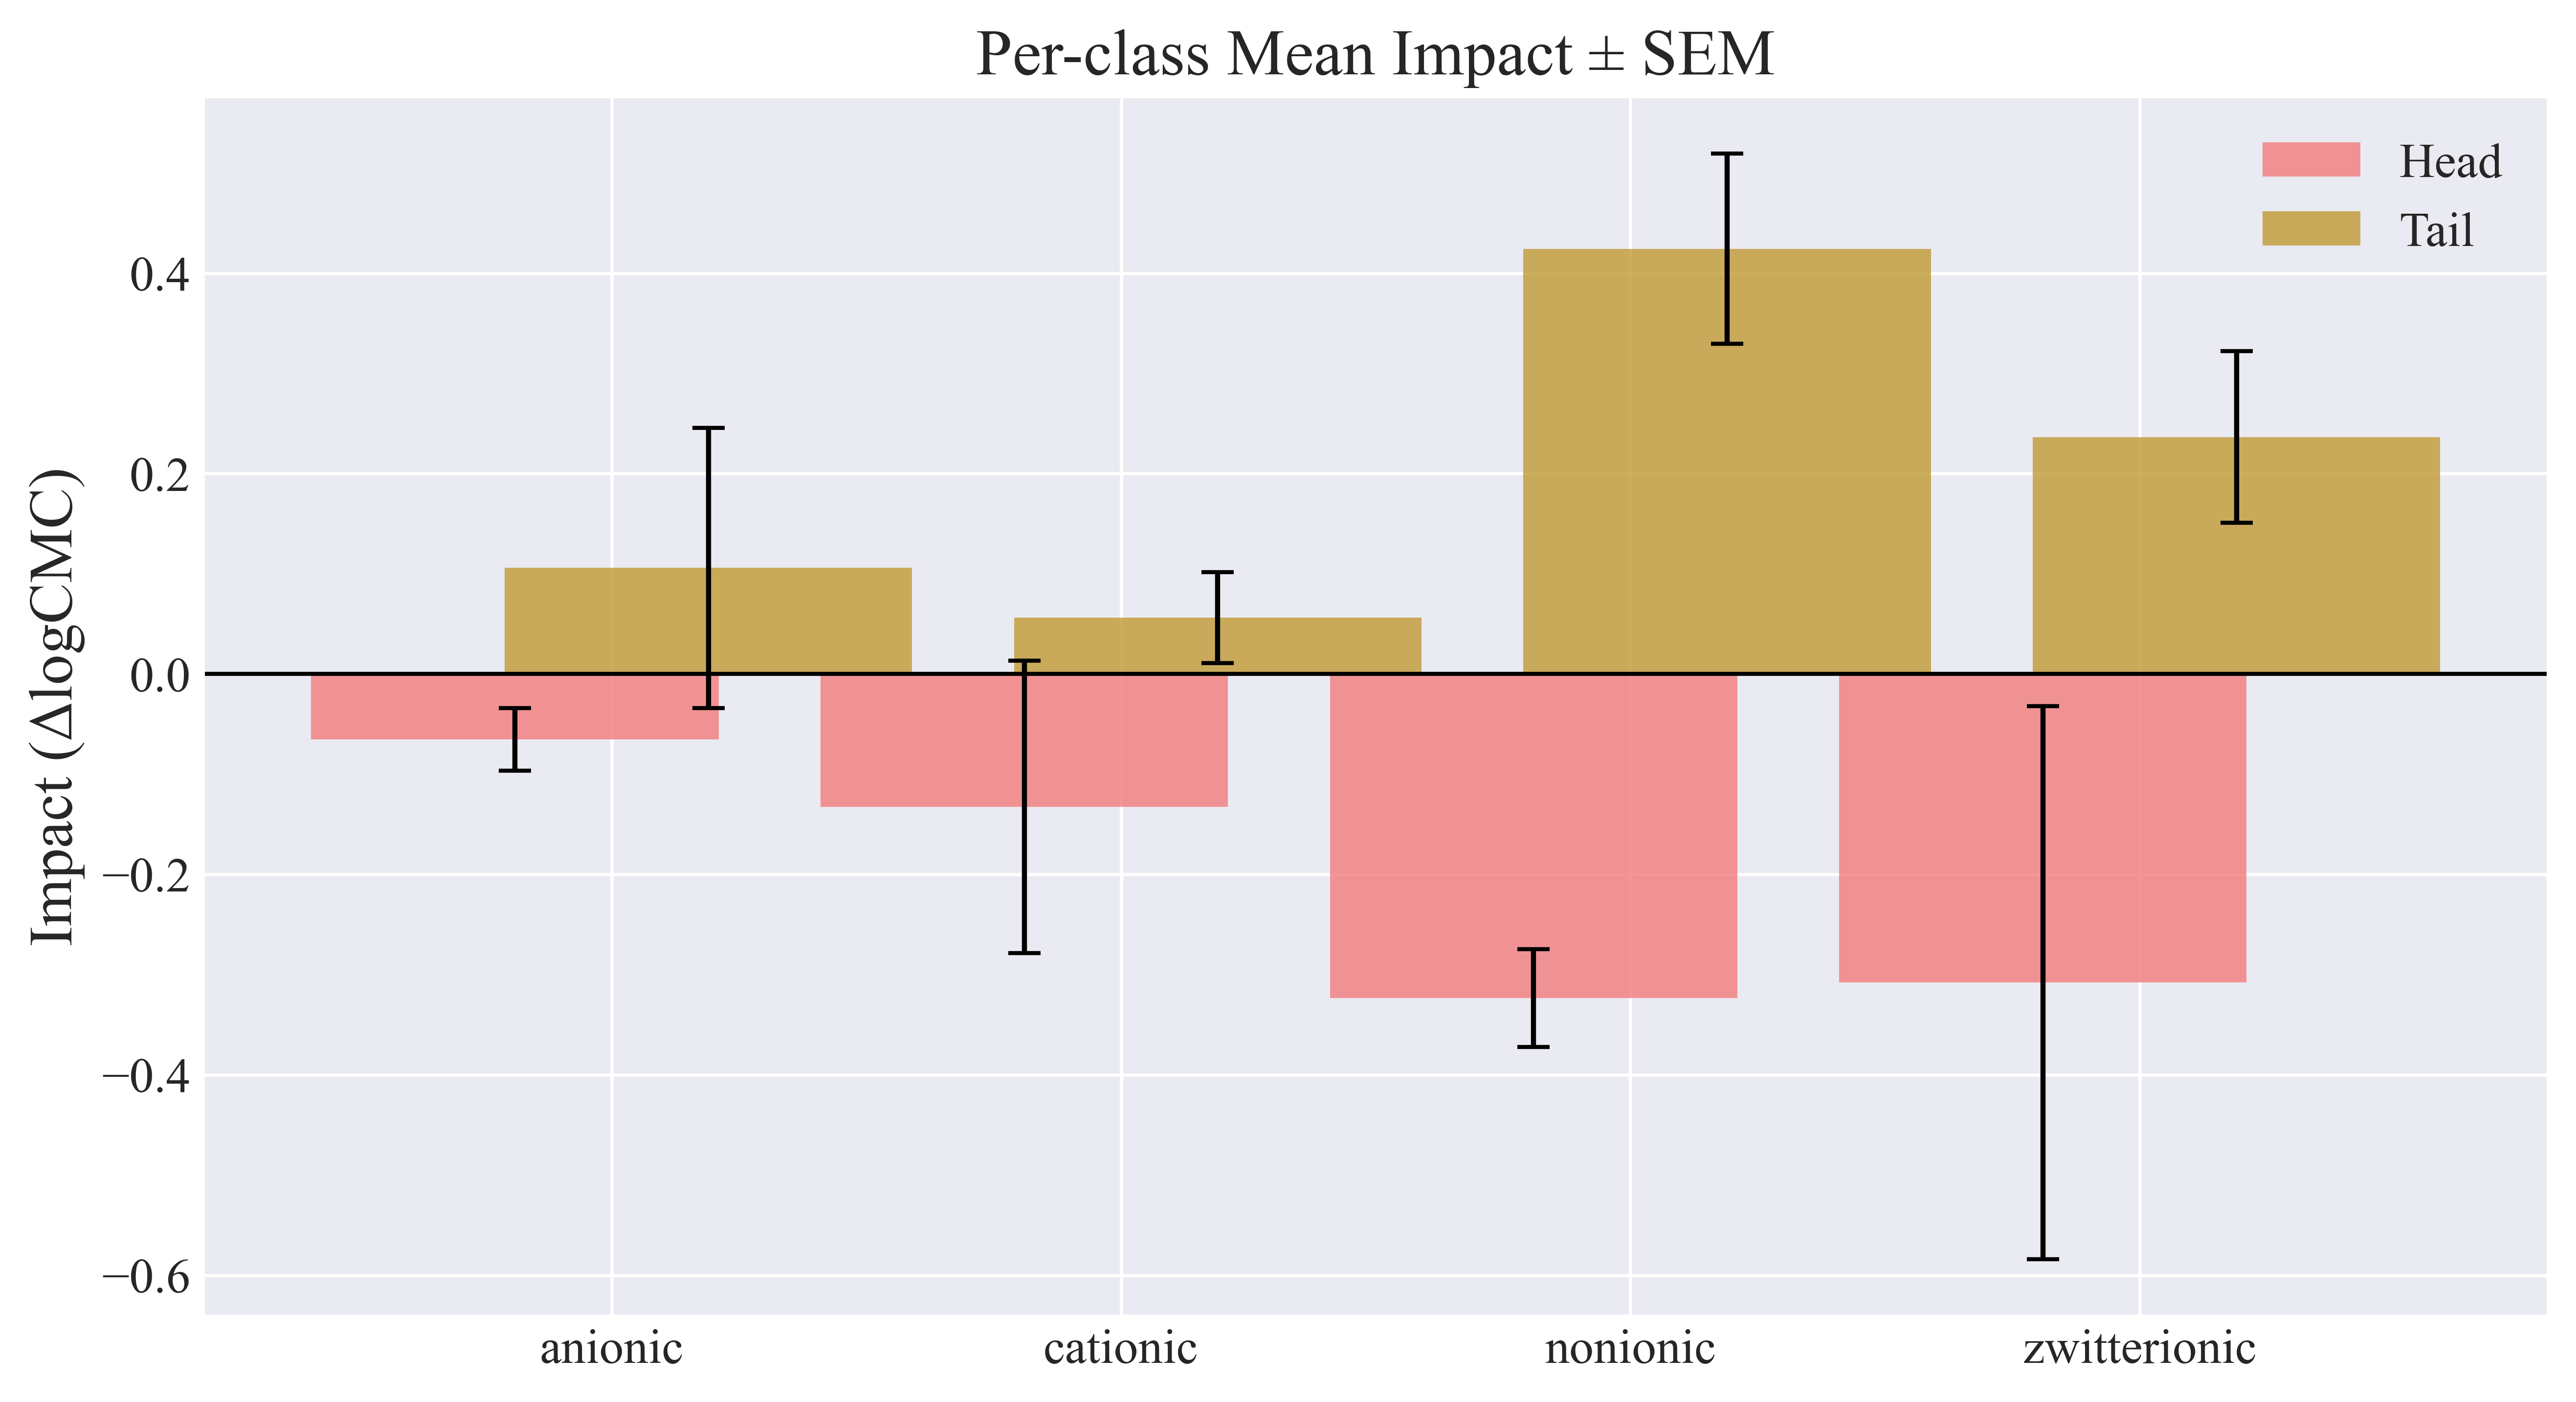

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make sure surf_type is lowercase and simple
results_df["surf_type"] = results_df["surf_type"].str.lower()

by_class = (
    results_df
    .groupby("surf_type")
    .agg(
        head_mean=("head_impact", "mean"),
        head_sem =("head_impact", lambda s: s.std(ddof=1)/np.sqrt(len(s)) if len(s)>1 else np.nan),
        tail_mean=("tail_impact", "mean"),
        tail_sem =("tail_impact", lambda s: s.std(ddof=1)/np.sqrt(len(s)) if len(s)>1 else np.nan),
        n=("smiles", "count")
    )
    .reset_index()
)

display(by_class)

plt.figure(figsize=(9,5))
x = np.arange(len(by_class))
w = 0.38

plt.bar(x - w/2, by_class["head_mean"],
        yerr=by_class["head_sem"], capsize=4,
        label="Head", alpha=0.8, color="#f27c7c")
plt.bar(x + w/2, by_class["tail_mean"],
        yerr=by_class["tail_sem"], capsize=4,
        label="Tail", alpha=0.8, color="#c19a34")

plt.axhline(0, color="k", lw=1)
plt.xticks(x, by_class["surf_type"])
plt.ylabel("Impact (ΔlogCMC)")
plt.title("Per-class Mean Impact ± SEM")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
from rdkit import Chem
from rdkit.Chem import Crippen
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) add tail_carbons and tail_logp to the *current* results_df
def _tail_features_from_smiles(smi: str):
    from data import identify_surfactant_features  # uses your existing logic

    # mol = Chem.MolFromSmiles(smi)
    # if mol is None:
    #     return np.nan, np.nan

    mol = Chem.MolFromSmiles(smi.split('.')[0] if '.' in smi else smi)
    if mol is None:
        return np.nan, np.nan

    info = identify_surfactant_features(mol)
    tail_atoms = list(info.get("tail_atoms", []))

    # count carbons in tail
    tail_carbons = sum(
        1 for i in tail_atoms
        if i < mol.GetNumAtoms() and mol.GetAtomWithIdx(i).GetSymbol() == "C"
    )

    # fragmental tail logP
    try:
        contribs = Crippen._CalcCrippenContribs(mol)
        valid_atoms = [i for i in tail_atoms if i < len(contribs)]
        # tail_logp = float(sum(contribs[i][0] for i in tail_atoms if i < mol.GetNumAtoms()))
        tail_logp = sum(contribs[i][0] for i in valid_atoms) if valid_atoms else np.nan
    except Exception:
        tail_logp = np.nan

    return tail_carbons, tail_logp



# actually add the columns (this is the missing piece)
results_df["tail_carbons"], results_df["tail_logp"] = zip(
    *results_df["smiles"].apply(_tail_features_from_smiles)
)

print(results_df[["smiles", "surf_type", "tail_carbons", "tail_logp"]].head())


                                              smiles surf_type  tail_carbons  \
0                            CCCCCCCCCCOCCOCCOCCOCCO  nonionic            10   
1  CCCCCCCCO[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@...  nonionic             8   
2  CCCCCCCCC=CCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O...  nonionic            18   
3  CCCCCCCC(=O)OCC(OCCOCCO)C1OCC(OCCOCCO)C1OCCOCC...  nonionic             8   
4  CCCCCCCC(=O)OCC(OCCOCCOCCO)C1OCC(OCCOCCO)C1OCC...  nonionic             8   

   tail_logp  
0        NaN  
1        NaN  
2        NaN  
3        NaN  
4        NaN  


In [16]:
# DEBUG: Test the function on one molecule
test_smi = results_df['smiles'].iloc[0]
print(f"Testing molecule: {test_smi}")

from data import identify_surfactant_features
mol = Chem.MolFromSmiles(test_smi.split('.')[0] if '.' in test_smi else test_smi)
info = identify_surfactant_features(mol)
tail_atoms = list(info.get("tail_atoms", []))

print(f"Tail atoms found: {tail_atoms}")
print(f"Number of tail atoms: {len(tail_atoms)}")

if tail_atoms:
    try:
        contribs = Crippen._CalcCrippenContribs(mol)
        print(f"Number of Crippen contributions: {len(contribs)}")
        valid_atoms = [i for i in tail_atoms if i < len(contribs)]
        print(f"Valid tail atoms: {valid_atoms}")
        tail_logp = sum(contribs[i][0] for i in valid_atoms) if valid_atoms else np.nan
        print(f"Calculated tail logP: {tail_logp}")
    except Exception as e:
        print(f"Error in logP calculation: {e}")
else:
    print("No tail atoms found!")

Testing molecule: CCCCCCCCCCOCCOCCOCCOCCO
Tail atoms found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of tail atoms: 10
Error in logP calculation: module 'rdkit.Chem.Crippen' has no attribute '_CalcCrippenContribs'


In [17]:
from rdkit import Chem
from rdkit.Chem import Crippen, rdMolDescriptors
import numpy as np

def _tail_features_from_smiles(smi: str):
    from data import identify_surfactant_features
    
    mol = Chem.MolFromSmiles(smi.split('.')[0] if '.' in smi else smi)
    if mol is None:
        return np.nan, np.nan

    info = identify_surfactant_features(mol)
    tail_atoms = list(info.get("tail_atoms", []))

    # count carbons in tail
    tail_carbons = sum(
        1 for i in tail_atoms
        if i < mol.GetNumAtoms() and mol.GetAtomWithIdx(i).GetSymbol() == "C"
    )

    # fragmental tail logP - TRY DIFFERENT METHODS
    try:
        # Method 1: Try rdMolDescriptors
        contribs = rdMolDescriptors._CalcCrippenContribs(mol)
        valid_atoms = [i for i in tail_atoms if i < len(contribs)]
        tail_logp = sum(contribs[i][0] for i in valid_atoms) if valid_atoms else np.nan
    except:
        try:
            # Method 2: Calculate full molecule logP for tail only
            # Create a new molecule with only tail atoms
            tail_logp = 0.0
            for atom_idx in tail_atoms:
                if atom_idx < mol.GetNumAtoms():
                    atom = mol.GetAtomWithIdx(atom_idx)
                    # Simple approximation: C contributes ~0.5, other atoms vary
                    if atom.GetSymbol() == 'C':
                        tail_logp += 0.5
        except:
            tail_logp = np.nan

    return tail_carbons, tail_logp

# Re-run the calculation
results_df["tail_carbons"], results_df["tail_logp"] = zip(
    *results_df["smiles"].apply(_tail_features_from_smiles)
)

print(results_df[["smiles", "surf_type", "tail_carbons", "tail_logp"]].head())

                                              smiles surf_type  tail_carbons  \
0                            CCCCCCCCCCOCCOCCOCCOCCO  nonionic            10   
1  CCCCCCCCO[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@...  nonionic             8   
2  CCCCCCCCC=CCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O...  nonionic            18   
3  CCCCCCCC(=O)OCC(OCCOCCO)C1OCC(OCCOCCO)C1OCCOCC...  nonionic             8   
4  CCCCCCCC(=O)OCC(OCCOCCOCCO)C1OCC(OCCOCCO)C1OCC...  nonionic             8   

   tail_logp  
0     1.0934  
1     0.8052  
2     2.2682  
3     0.7304  
4     0.7304  


In [19]:
display(by_class)

,surf_type,head_mean,head_sem,tail_mean,tail_sem,n
0,anionic,-0.065248,0.031158,0.105758,0.139686,10
1,cationic,-0.132665,0.145828,0.056325,0.045453,4
2,nonionic,-0.323367,0.048914,0.424313,0.094998,59
3,zwitterionic,-0.308111,0.275892,0.236420,0.085537,2


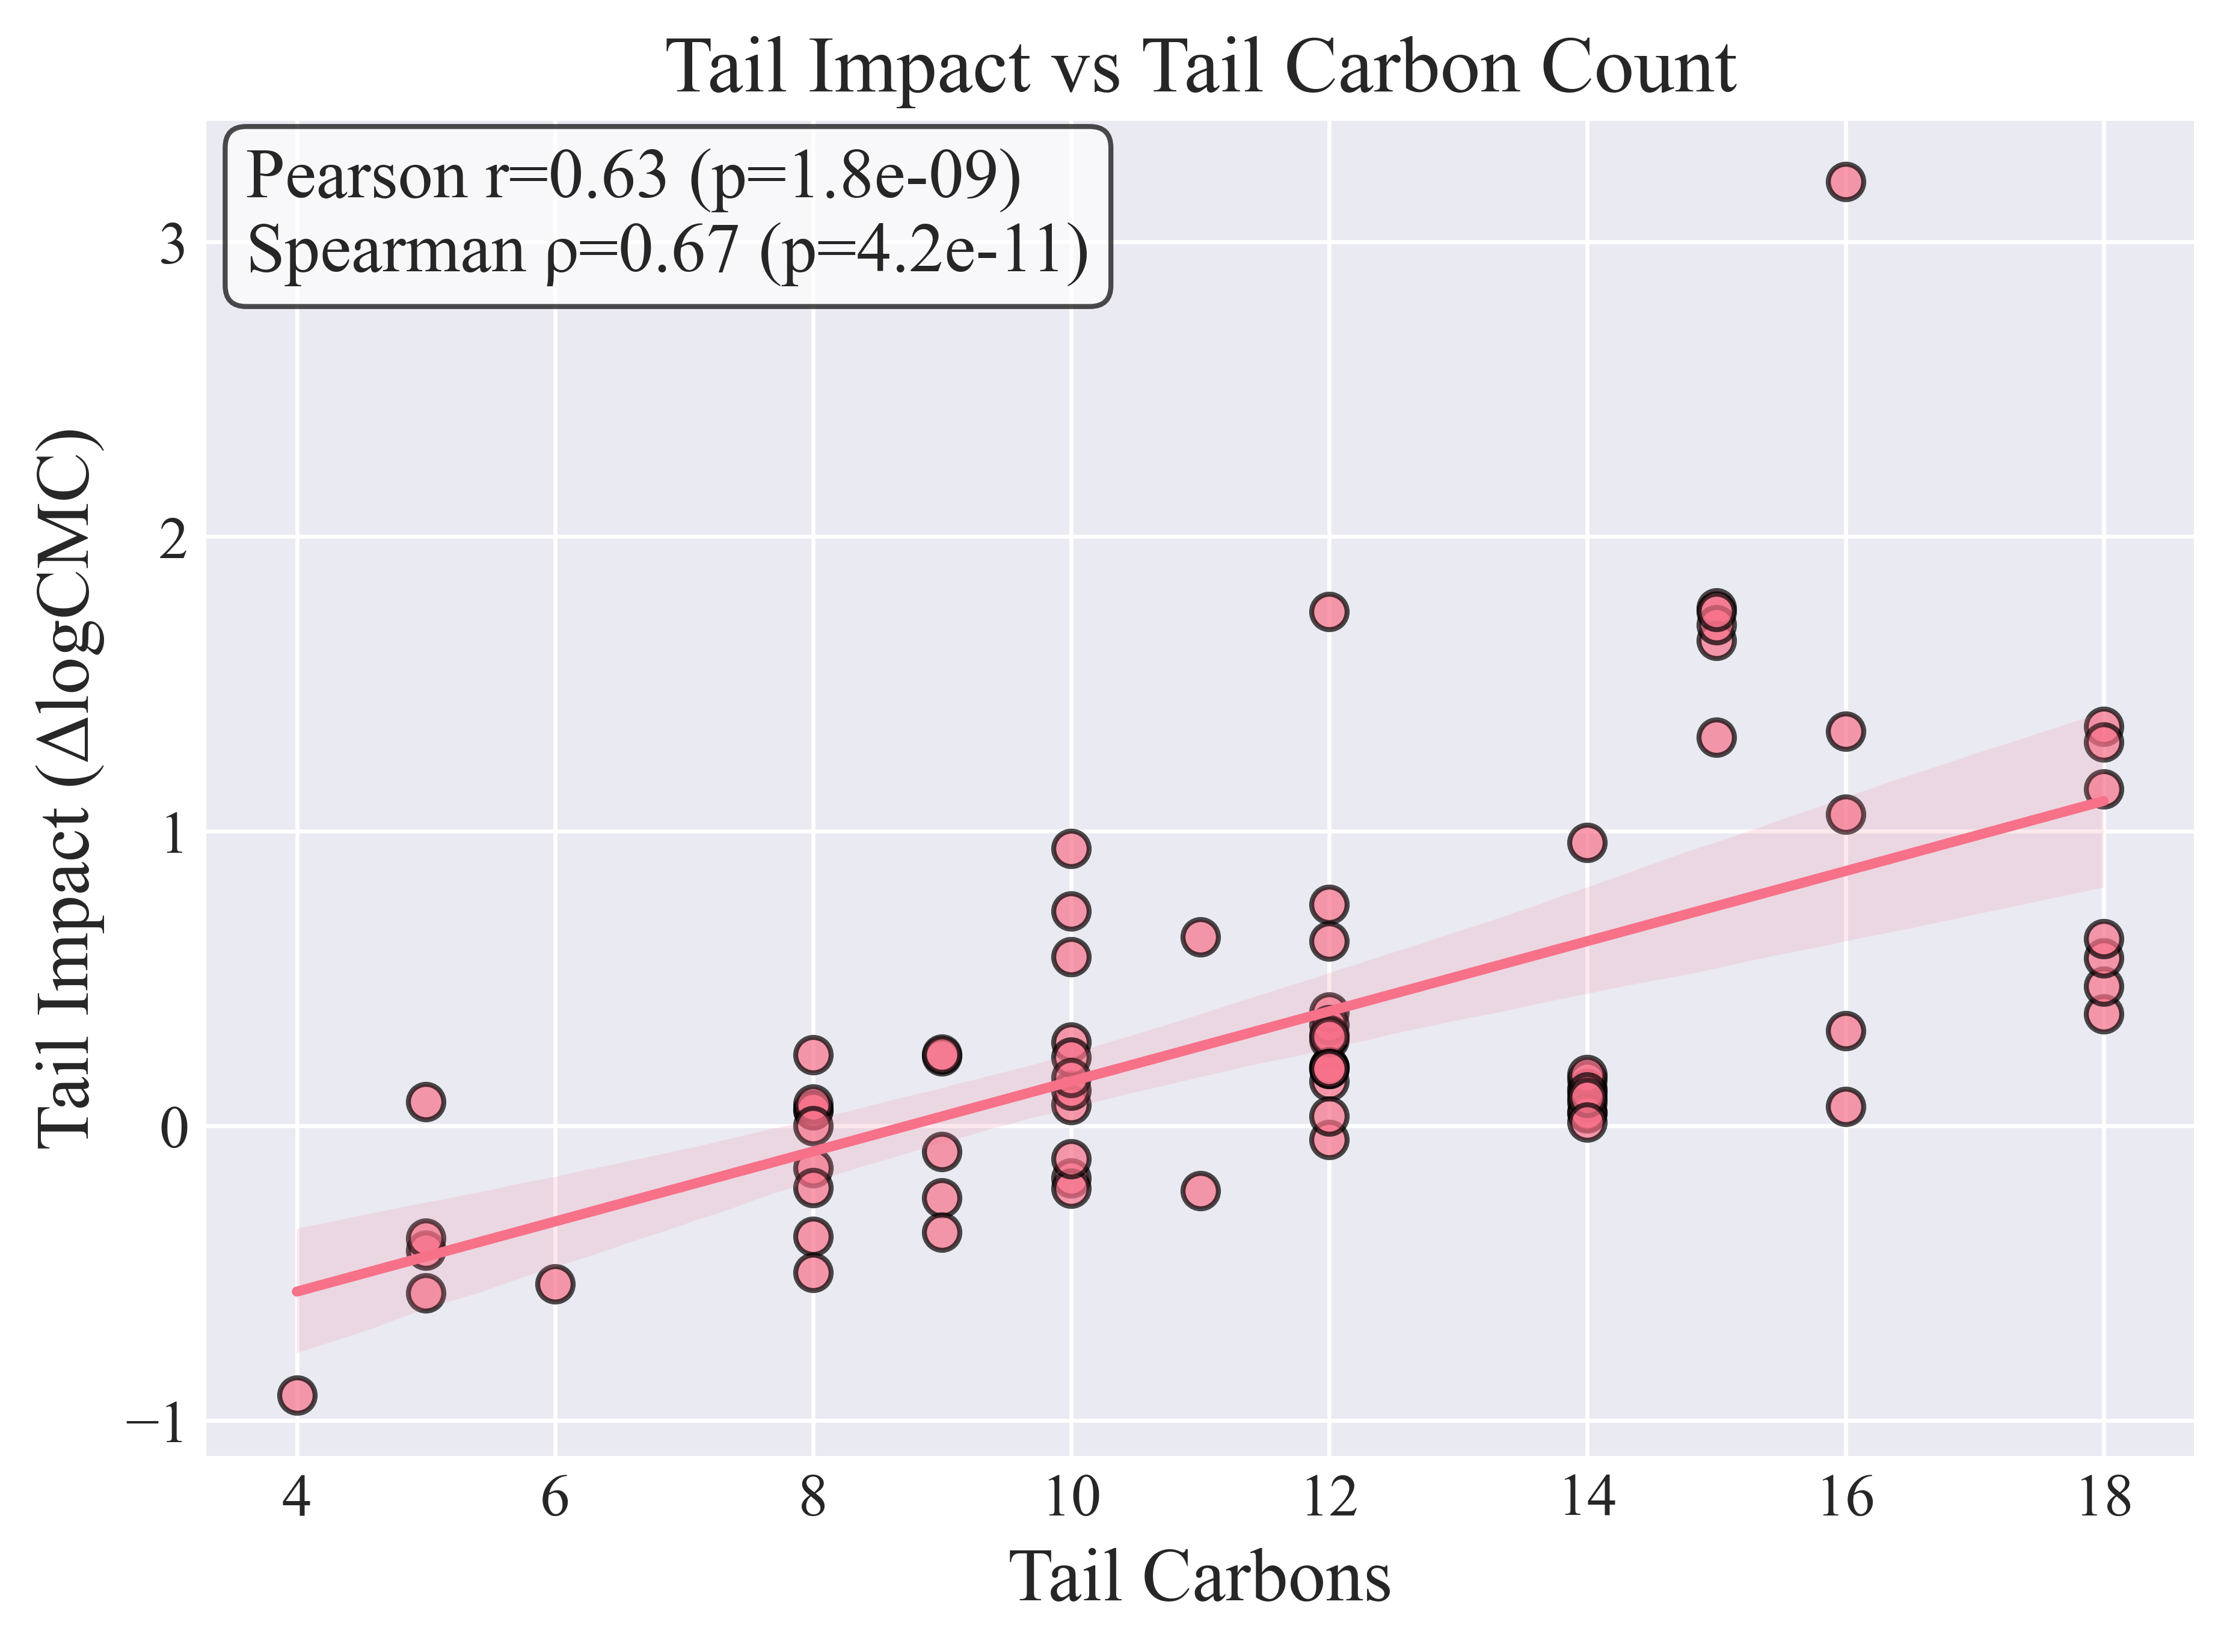

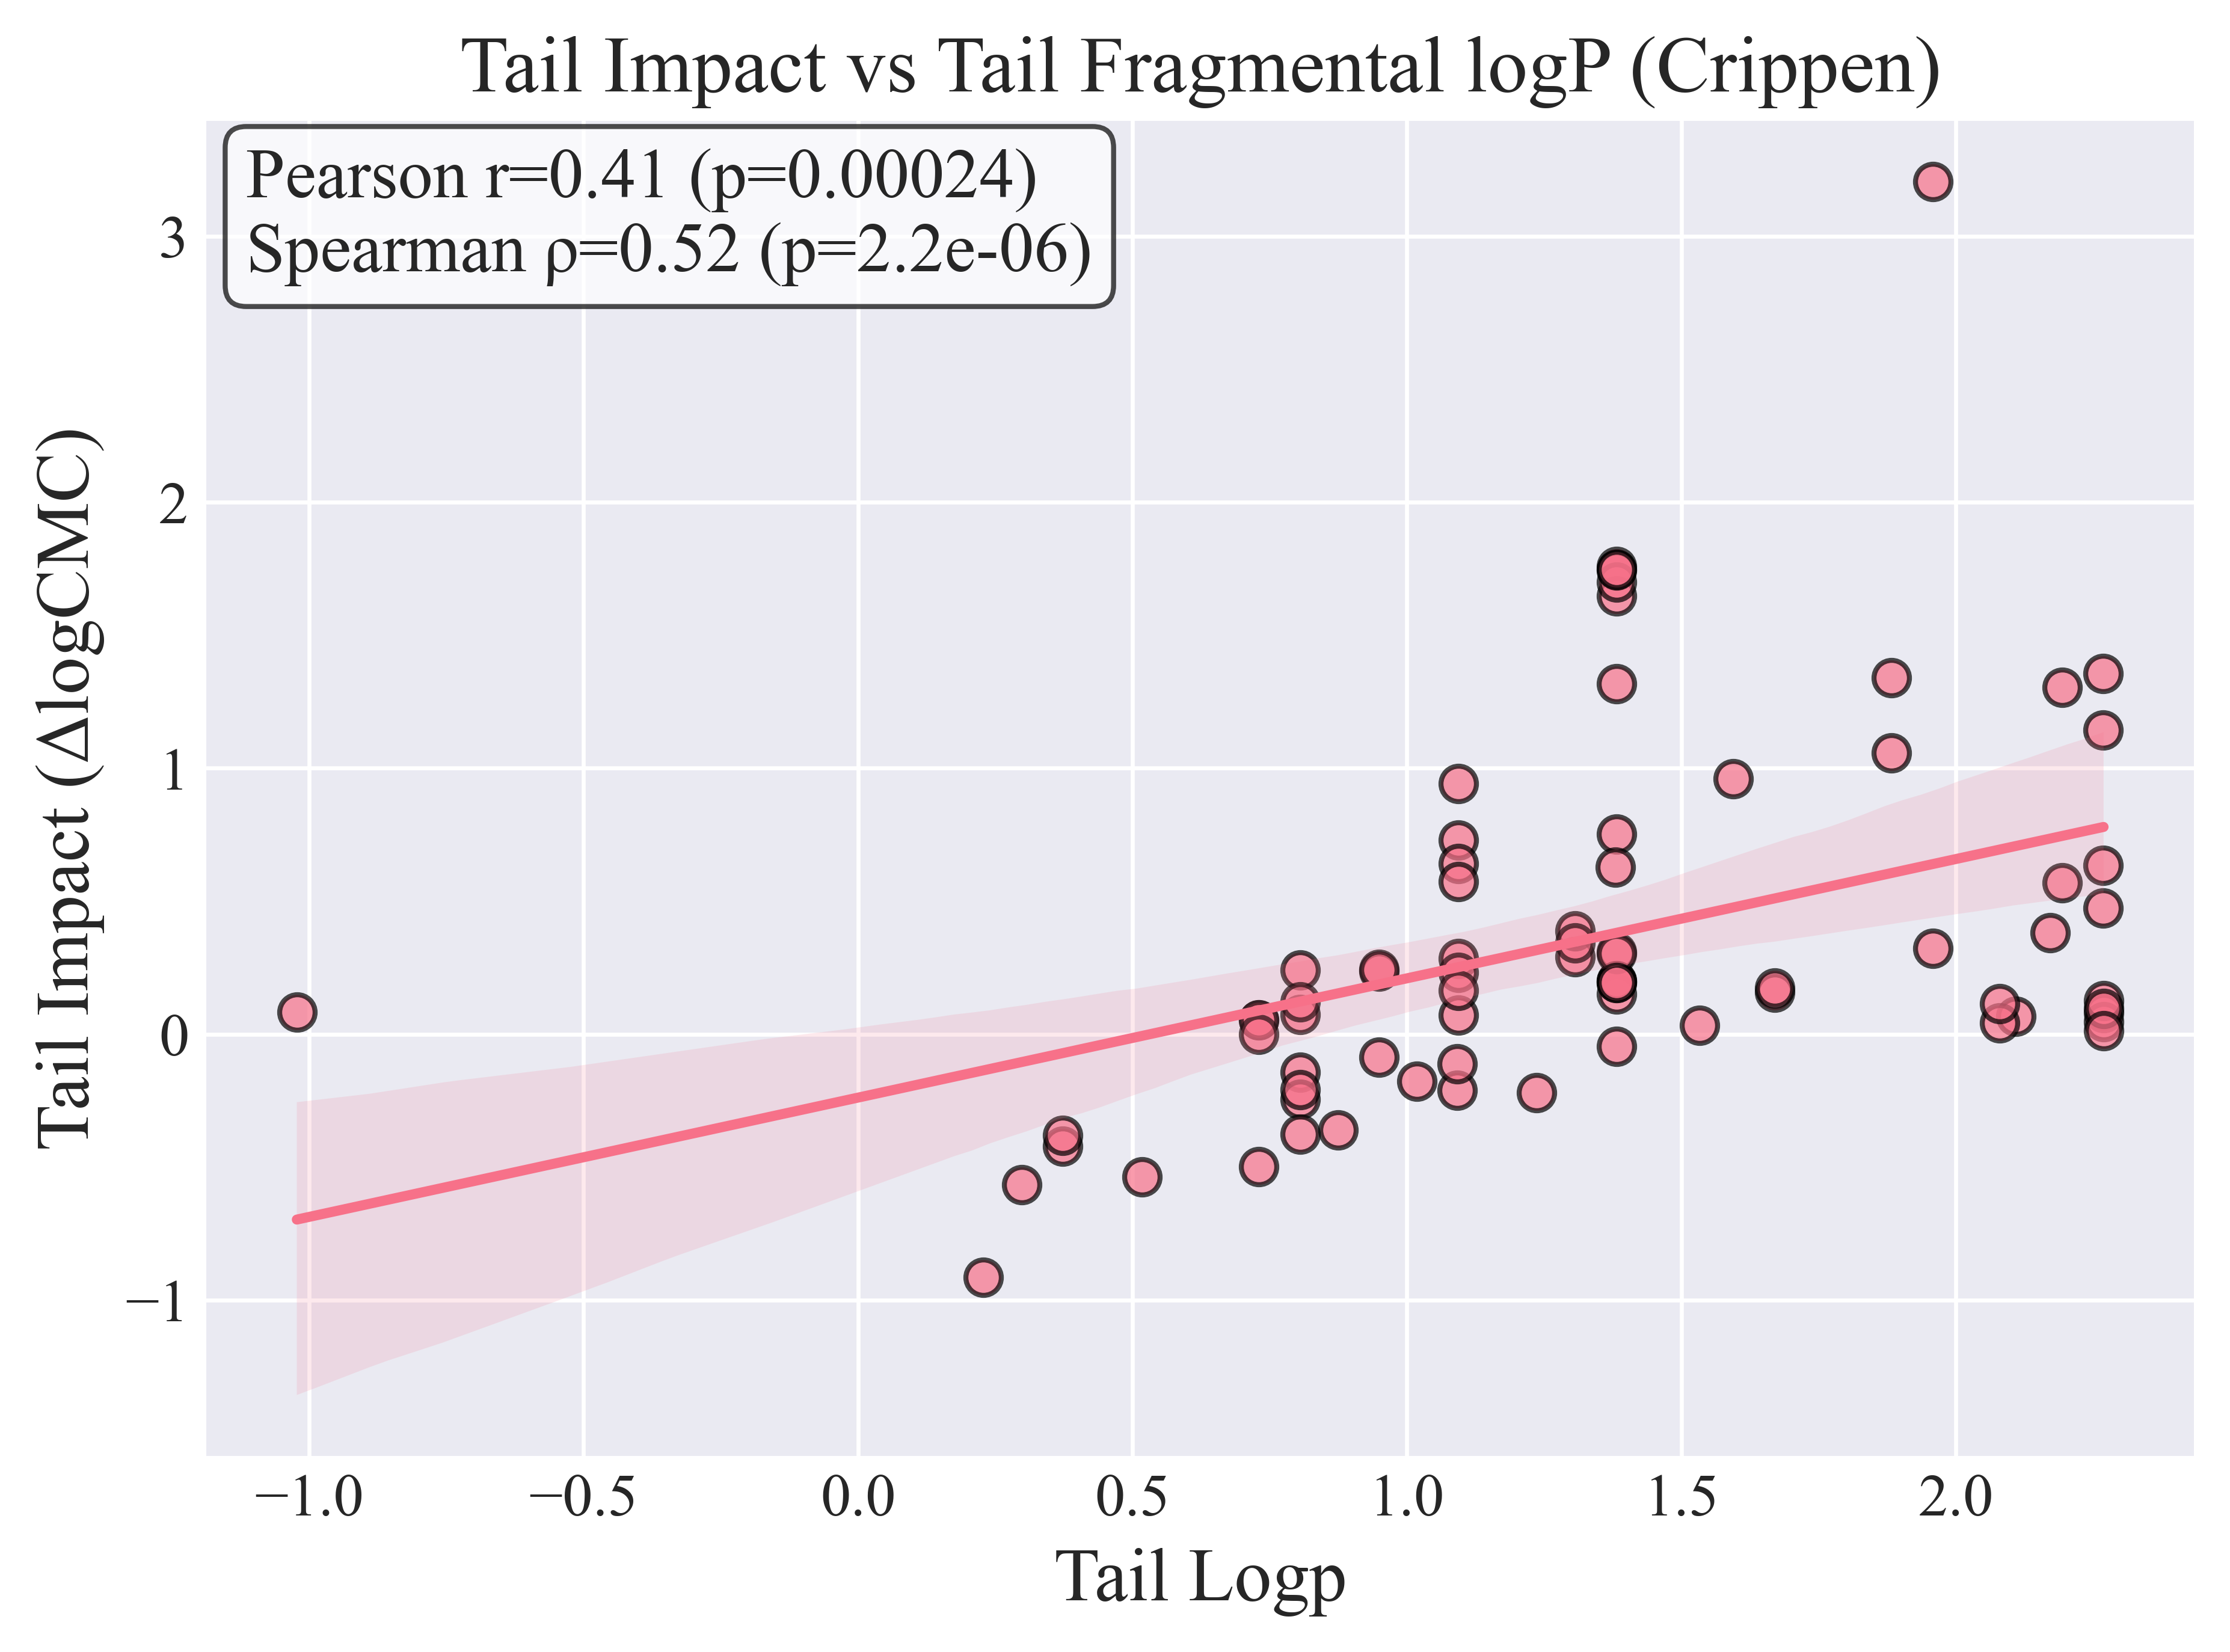

In [18]:
from scipy import stats

def scatter_with_fit(df, xcol, ycol="tail_impact", title=""):
    sub = df[[xcol, ycol]].dropna()
    if len(sub) < 3:
        print(f"Not enough points for {xcol}")
        return

    ax = sns.regplot(
        data=sub, x=xcol, y=ycol,
        scatter_kws=dict(s=50, alpha=0.7, edgecolor="black"),
        line_kws=dict(lw=2)
    )
    ax.set_xlabel(xcol.replace("_", " ").title())
    ax.set_ylabel("Tail Impact (ΔlogCMC)")
    ax.set_title(title or f"Tail Impact vs {xcol}")

    pearson = stats.pearsonr(sub[xcol], sub[ycol])
    spearman = stats.spearmanr(sub[xcol], sub[ycol])

    ax.text(
        0.02, 0.98,
        f"Pearson r={pearson.statistic:.2f} (p={pearson.pvalue:.2g})\n"
        f"Spearman ρ={spearman.statistic:.2f} (p={spearman.pvalue:.2g})",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )
    plt.tight_layout()
    plt.show()

# 3a) Tail impact vs tail carbon count
scatter_with_fit(
    results_df,
    "tail_carbons",
    ycol="tail_impact",
    title="Tail Impact vs Tail Carbon Count"
)

# 3b) Tail impact vs tail fragmental logP
scatter_with_fit(
    results_df,
    "tail_logp",
    ycol="tail_impact",
    title="Tail Impact vs Tail Fragmental logP (Crippen)"
)


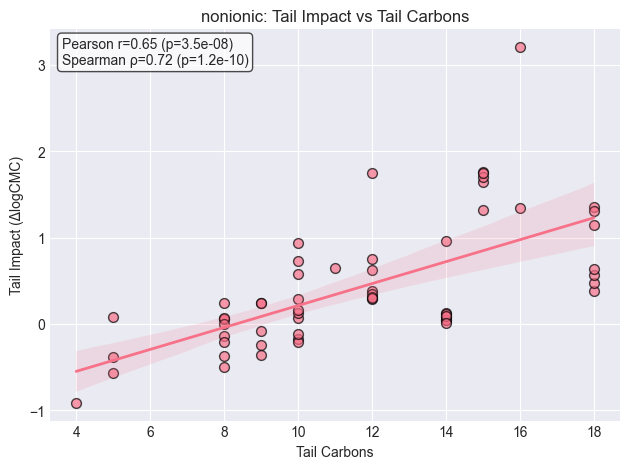

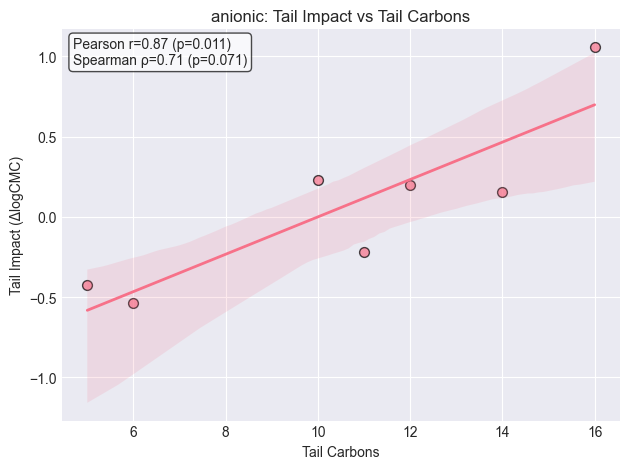

In [37]:
for cls in results_df["surf_type"].dropna().unique():
    sub = results_df[results_df["surf_type"] == cls]
    if len(sub) < 5:
        continue
    scatter_with_fit(
        sub,
        "tail_carbons",
        ycol="tail_impact",
        title=f"{cls}: Tail Impact vs Tail Carbons"
    )
